**Run note:** execute this notebook's first setup/code cell before any later cells. Each notebook is designed to run independently and re-detect the dataset path on its own.

# 04 â€” OCR Pipeline

The Meta Hateful Memes dataset ships with human-cleaned OCR text in the `text` field. This notebook:
1. Audits the quality of the existing OCR text
2. Runs EasyOCR on a sample to compare
3. Decides whether to augment/replace the dataset OCR
4. Stores a final enhanced text column for downstream use

In [44]:
import os
import json
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from PIL import Image

ON_KAGGLE = Path("/kaggle/input").is_dir()
JSONL_CANDIDATES = {
    "train": ["train.jsonl"],
    "dev": ["dev.jsonl", "dev_seen.jsonl", "dev_unseen.jsonl"],
    "test": ["test.jsonl", "test_seen.jsonl", "test_unseen.jsonl"],
}
IMAGE_DIR_CANDIDATES = ("img", "images")


def _has_image_dir(path: Path) -> bool:
    return any((path / name).is_dir() for name in IMAGE_DIR_CANDIDATES)


def _has_any_jsonl(path: Path, names) -> bool:
    return any((path / name).is_file() for name in names)


def _looks_like_dataset_root(path: Path) -> bool:
    return path.is_dir() and _has_image_dir(path) and _has_any_jsonl(path, JSONL_CANDIDATES["train"])


def detect_data_dir():
    for env_name in ("KAGGLE_DATA_DIR", "META_HATEFUL_MEME_DATA_DIR"):
        env_dir = os.environ.get(env_name, "").strip()
        if env_dir and _looks_like_dataset_root(Path(env_dir)):
            return Path(env_dir), f"env:{env_name}"

    kaggle_input = Path("/kaggle/input")
    default_candidate = kaggle_input / "meta-hateful-meme-detection" / "data"
    if _looks_like_dataset_root(default_candidate):
        return default_candidate, "default:/kaggle/input/meta-hateful-meme-detection/data"

    if ON_KAGGLE:
        for train_jsonl in sorted(kaggle_input.rglob("train.jsonl")):
            candidate = train_jsonl.parent
            if _looks_like_dataset_root(candidate):
                return candidate, f"auto:{candidate}"

        for candidate in sorted(kaggle_input.rglob("*")):
            if candidate.is_dir() and _looks_like_dataset_root(candidate):
                return candidate, f"auto:{candidate}"

    for candidate in (Path.cwd() / "data", Path.cwd().parent / "data", Path.cwd(), Path.cwd().parent):
        if _looks_like_dataset_root(candidate):
            return candidate, f"local:{candidate}"

    return None, "not-found"


def resolve_split(base_dir, names):
    base_dir = Path(base_dir)
    for name in names:
        path = base_dir / name
        if path.is_file():
            return path
    for name in names:
        matches = sorted(base_dir.rglob(name))
        if matches:
            return matches[0]
    return None


DATA_DIR, data_source = detect_data_dir()
if DATA_DIR is None:
    raise FileNotFoundError(
        "Dataset not found. Set KAGGLE_DATA_DIR or META_HATEFUL_MEME_DATA_DIR to the folder containing train.jsonl and img/."
    )

IMG_DIR = next((DATA_DIR / name for name in IMAGE_DIR_CANDIDATES if (DATA_DIR / name).is_dir()), None)
TRAIN_PATH = resolve_split(DATA_DIR, JSONL_CANDIDATES["train"])
DEV_PATH = resolve_split(DATA_DIR, JSONL_CANDIDATES["dev"])
TEST_PATH = resolve_split(DATA_DIR, JSONL_CANDIDATES["test"])
OUTPUT_DIR = Path("/kaggle/working") if ON_KAGGLE else Path.cwd() / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

if TRAIN_PATH is None or DEV_PATH is None or TEST_PATH is None:
    raise FileNotFoundError(f"Expected train/dev/test splits under {DATA_DIR}")

DATA_DIR = str(DATA_DIR)
IMG_DIR = str(IMG_DIR) if IMG_DIR is not None else None
TRAIN_PATH = str(TRAIN_PATH)
DEV_PATH = str(DEV_PATH)
TEST_PATH = str(TEST_PATH)
OUTPUT_DIR = str(OUTPUT_DIR)

print(f"Using DATA_DIR : {DATA_DIR}")
print(f"Using IMG_DIR  : {IMG_DIR}")
print(f"Using source   : {data_source}")
print(f"Output dir     : {OUTPUT_DIR}")


def load_jsonl(path):
    with open(path, encoding="utf-8") as f:
        return pd.DataFrame([json.loads(l) for l in f])


train = load_jsonl(TRAIN_PATH)
dev = load_jsonl(DEV_PATH)
test = load_jsonl(TEST_PATH)

print(f"Loaded: train={len(train)}, dev={len(dev)}, test={len(test)}")

Using DATA_DIR : /kaggle/input/datasets/muddybuddy/meta-hateful-meme-detection/data
Using IMG_DIR  : /kaggle/input/datasets/muddybuddy/meta-hateful-meme-detection/data/img
Using source   : auto:/kaggle/input/datasets/muddybuddy/meta-hateful-meme-detection/data
Output dir     : /kaggle/working
Loaded: train=8500, dev=500, test=1000


In [45]:
# â”€â”€ 4.1 Audit existing dataset OCR â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
# Text quality metrics
train["text_len"]      = train["text"].str.len()
train["word_count"]    = train["text"].str.split().str.len()
train["has_text"]      = train["text"].str.strip().str.len() > 0
train["is_short"]      = train["word_count"] <= 2
train["has_numbers"]   = train["text"].str.contains(r"\d", regex=True)
train["has_special"]   = train["text"].str.contains(r"[^a-zA-Z0-9 '!?,.-]", regex=True)

print("Dataset OCR quality audit:")
print(f"  Samples with text      : {train.has_text.sum():,} / {len(train):,}")
print(f"  Very short (<=2 words) : {train.is_short.sum():,}")
print(f"  Contains numbers       : {train.has_numbers.sum():,}")
print(f"  Contains special chars : {train.has_special.sum():,}")
print(f"  Avg word count         : {train.word_count.mean():.2f}")
print(f"  Avg char count         : {train.text_len.mean():.1f}")

Dataset OCR quality audit:
  Samples with text      : 8,500 / 8,500
  Very short (<=2 words) : 153
  Contains numbers       : 762
  Contains special chars : 1,010
  Avg word count         : 11.74
  Avg char count         : 62.1


In [46]:
# â”€â”€ 4.2 Show very short / suspicious OCR entries â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
suspicious = train[train["word_count"] <= 1].sample(min(10, (train.word_count <= 1).sum()), random_state=42)
print("Samples with â‰¤1 word in OCR text:")
for _, row in suspicious.iterrows():
    print(f"  id={row.id}  label={row.label}  text='{row.text}'")

Samples with â‰¤1 word in OCR text:
  id=74096  label=0  text='him:'
  id=16439  label=1  text='cannibalism'
  id=4876  label=0  text='goin'
  id=34786  label=0  text='same'
  id=61743  label=1  text='same'
  id=68120  label=1  text='fleshlight'
  id=70183  label=1  text='terminigger'
  id=19036  label=0  text='infamous'
  id=4891  label=0  text='cannibalism'
  id=69237  label=0  text='temptations'


In [47]:
# â”€â”€ 4.3 Install & run EasyOCR on sample images â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
# EasyOCR is GPU-accelerated on Kaggle. First install if needed.
import subprocess, sys
try:
    import easyocr
    print("easyocr already installed")
except ImportError:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "easyocr"], check=True)
    import easyocr
    print("easyocr installed")

import torch
import easyocr

USE_GPU = torch.cuda.is_available()
reader  = easyocr.Reader(["en"], gpu=USE_GPU, verbose=False)
print(f"EasyOCR reader initialized (GPU={USE_GPU})")

easyocr already installed
EasyOCR reader initialized (GPU=True)


In [48]:
# â”€â”€ 4.4 Compare dataset OCR vs EasyOCR on 20 samples â”€â”€â”€â”€â”€â”€â”€â”€â”€
import re

def run_easyocr(img_path, reader):
    try:
        results = reader.readtext(img_path, detail=0, paragraph=True)
        return " ".join(results).strip()
    except Exception as e:
        return ""

def clean_ocr(text):
    """Basic OCR output cleaning."""
    text = re.sub(r"\s+", " ", text)          # collapse whitespace
    text = text.strip()
    return text

sample_20 = train.sample(20, random_state=42)
comparisons = []

print("Running EasyOCR on 20 samples...")
for i, (_, row) in enumerate(sample_20.iterrows()):
    img_path  = os.path.join(DATA_DIR, row["img"])
    easy_text = clean_ocr(run_easyocr(img_path, reader))
    comparisons.append({
        "id"         : row["id"],
        "dataset_text": row["text"],
        "easyocr_text": easy_text,
        "label"      : row["label"],
    })
    if (i + 1) % 5 == 0:
        print(f"  {i+1}/20 done")

cmp_df = pd.DataFrame(comparisons)
print("\nComparison (first 5):")
for _, r in cmp_df.head(5).iterrows():
    print(f"  Dataset : {r.dataset_text[:80]}")
    print(f"  EasyOCR : {r.easyocr_text[:80]}")
    print()

Running EasyOCR on 20 samples...
  5/20 done
  10/20 done
  15/20 done
  20/20 done

Comparison (first 5):
  Dataset : the latest toy has hit the shops it's a talking muslim doll nobody knows what th
  EasyOCR : (he lates_ toy has hhit the shons [Csa talking muslim doll mobody knows what the

  Dataset : show intolerance for other's religions expect highest level of tolerance for the
  EasyOCR : Show imtolerance for other"S [religftoms extpectliglesu levelol @olerance for Wh

  Dataset : if theres even one homeless child in america we have no room for illegal aliens
  EasyOCR : [f theres evem @me hompeless child im america we [have m@ roon for Mnedall annem

  Dataset : the look he gives you when you're the new goat in town
  EasyOCR : the Jook he gives VOu mben joute Ue ,eh goat in town

  Dataset : when people are still talking about epstein's pedo ring after 3 mass shootings i
  EasyOCR : when [peoile are stIl @alkiing about eqsteinFs edlo riing after 3 masS shootngs 



Mean word overlap (dataset OCR vs EasyOCR): 0.595
Samples with >0.7 overlap: 7 / 20


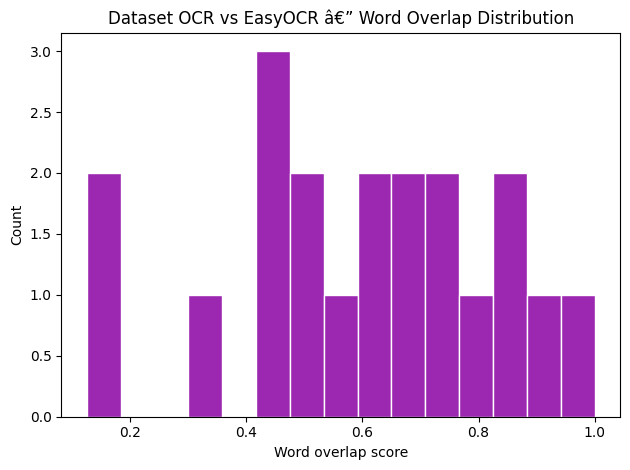

In [49]:
# â”€â”€ 4.5 OCR coverage & quality score â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
# Simple metric: character overlap between dataset OCR and easyOCR
def char_overlap_score(text1, text2):
    """Proportion of chars in text1 that appear in lowercased text2."""
    if not text1 or not text2:
        return 0.0
    s1 = set(text1.lower().split())
    s2 = set(text2.lower().split())
    if not s1:
        return 0.0
    return len(s1 & s2) / len(s1)

cmp_df["overlap"] = cmp_df.apply(
    lambda r: char_overlap_score(r.dataset_text, r.easyocr_text), axis=1
)

print(f"Mean word overlap (dataset OCR vs EasyOCR): {cmp_df.overlap.mean():.3f}")
print(f"Samples with >0.7 overlap: {(cmp_df.overlap > 0.7).sum()} / {len(cmp_df)}")

plt.hist(cmp_df["overlap"], bins=15, color="#9C27B0", edgecolor="white")
plt.xlabel("Word overlap score")
plt.ylabel("Count")
plt.title("Dataset OCR vs EasyOCR â€” Word Overlap Distribution")
plt.tight_layout()
plt.show()

In [50]:
# â”€â”€ 4.6 Decision: use dataset text as primary + EasyOCR fallback â”€
# The Meta dataset text is human-verified, so we prioritize it.
# EasyOCR is used as fallback for empty/very short dataset text.

def get_best_text(row_text, easy_text, min_words=2):
    dataset_words = len(str(row_text).split()) if row_text else 0
    easy_words    = len(str(easy_text).split()) if easy_text else 0
    # Use dataset OCR if it has enough words
    if dataset_words >= min_words:
        return str(row_text)
    # Fallback to EasyOCR
    if easy_words >= min_words:
        return str(easy_text)
    # Last resort: whatever is longer
    return str(row_text) if dataset_words >= easy_words else str(easy_text)

print("Decision: Dataset OCR text is high quality (human-verified).")
print("Strategy: use 'text' field as primary. EasyOCR as fallback for empty entries.")
print()
print("For full dataset EasyOCR extraction, uncomment the loop below.")
print("(Runs ~20-30 min on T4 for full train set â€” skip if dataset text is sufficient)")

Decision: Dataset OCR text is high quality (human-verified).
Strategy: use 'text' field as primary. EasyOCR as fallback for empty entries.

For full dataset EasyOCR extraction, uncomment the loop below.
(Runs ~20-30 min on T4 for full train set â€” skip if dataset text is sufficient)


In [51]:
# â”€â”€ 4.7 (OPTIONAL) Full EasyOCR pass & save â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
# Uncomment if you want full EasyOCR extraction for all splits.
# This takes ~20 min on T4 GPU for the full train set.

RUN_FULL_OCR = False  # Set to True to enable

if RUN_FULL_OCR:
    for split_name, df in [("train", train), ("dev", dev), ("test", test)]:
        print(f"Processing {split_name}...")
        easy_texts = []
        for idx, (_, row) in enumerate(df.iterrows()):
            img_path  = os.path.join(DATA_DIR, row["img"])
            easy_text = clean_ocr(run_easyocr(img_path, reader))
            final_text = get_best_text(row["text"], easy_text)
            easy_texts.append(final_text)
            if (idx + 1) % 500 == 0:
                print(f"  {idx+1}/{len(df)} done")
        df["enhanced_text"] = easy_texts
        out_path = os.path.join(OUTPUT_DIR, f"{split_name}_ocr.jsonl")
        df[["id", "img", "label", "text", "enhanced_text"]].to_json(
            out_path, orient="records", lines=True
        )
        print(f"  Saved to {out_path}")
else:
    print("Full OCR skipped. Using dataset 'text' field as-is.")
    print("Add enhanced_text = text for now:")
    for df in [train, dev, test]:
        df["enhanced_text"] = df["text"]
    print("  Done. 'enhanced_text' column added.")

Full OCR skipped. Using dataset 'text' field as-is.
Add enhanced_text = text for now:
  Done. 'enhanced_text' column added.


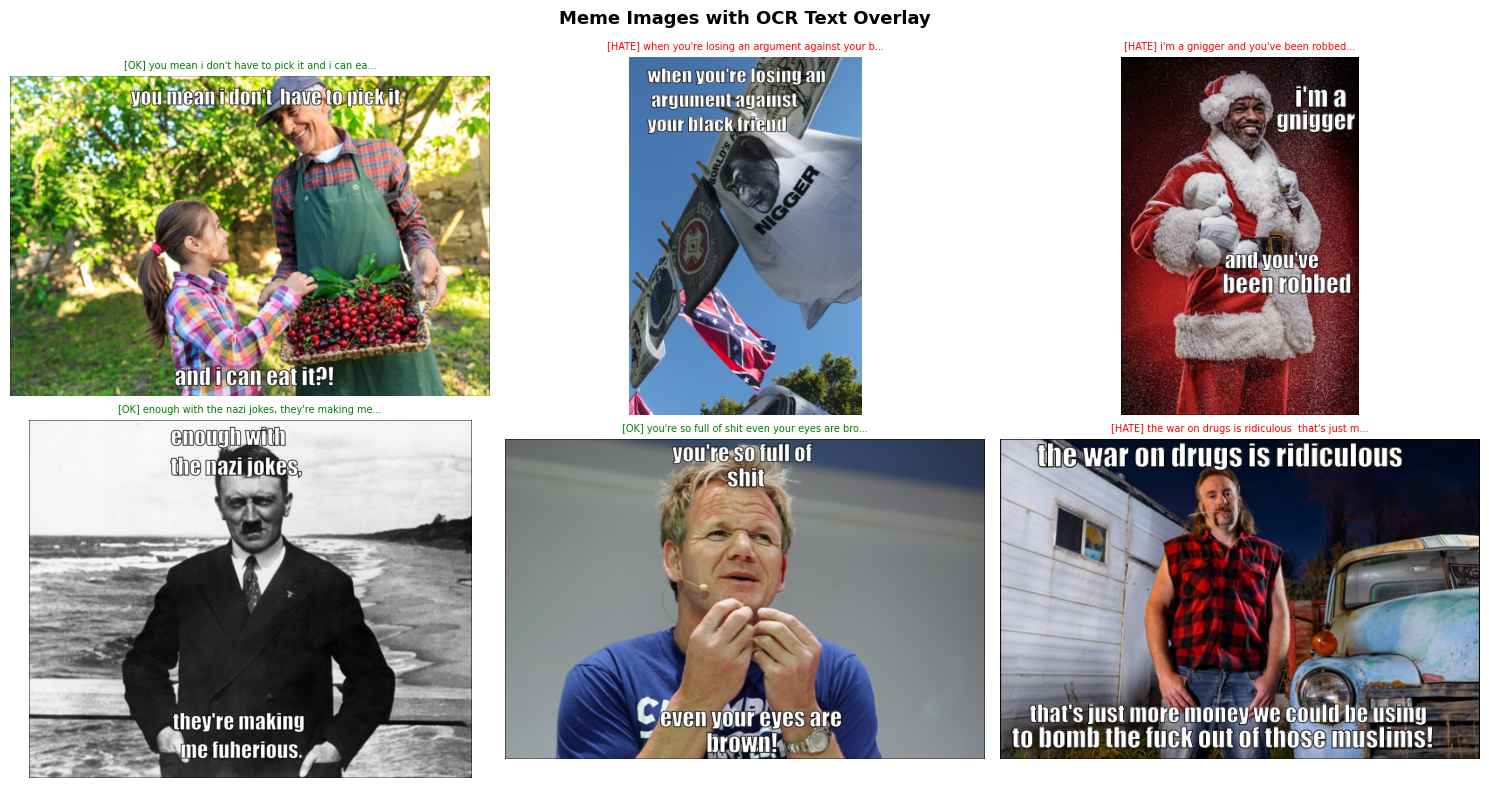

OCR pipeline complete. Proceed to notebook 05 (Preprocessing).


In [52]:
# â”€â”€ 4.8 Show OCR side-by-side with image â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle("Meme Images with OCR Text Overlay", fontsize=13, fontweight="bold")

samples = train.sample(6, random_state=7)
for ax, (_, row) in zip(axes.flat, samples.iterrows()):
    img_path = os.path.join(DATA_DIR, row["img"])
    try:
        ax.imshow(mpimg.imread(img_path))
    except:
        pass
    label_str = "HATE" if row.label == 1 else "OK"
    color = "red" if row.label == 1 else "green"
    ax.set_title(f"[{label_str}] {row.text[:45]}...", fontsize=7, color=color)
    ax.axis("off")

plt.tight_layout()
plt.show()
print("OCR pipeline complete. Proceed to notebook 05 (Preprocessing).")